# Stellar Classification: Machine Learning Tutorial

## Overview

This tutorial demonstrates machine learning classification techniques using real astronomical data from the **Sloan Digital Sky Survey (SDSS)**. The goal is to classify stars as either:
- **Class 0**: Normal Stars
- **Class 1**: RR Lyrae Variable Stars

### What are RR Lyrae Stars?

**RR Lyrae stars** are an important class of variable stars that exhibit regular, short-period brightness oscillations (typically 0.2-1 day periods). They are:
- **Evolutionary markers**: Found primarily in old stellar populations
- **Distance indicators**: Used to measure distances to nearby galaxies and globular clusters
- **Scientific importance**: Help us understand stellar evolution and galaxy structure

### Dataset Description

We use the **RR Lyrae Combined Dataset** from the AstroML library, which contains photometric observations from the SDSS. The dataset includes:

**Features** (4 photometric color indices):
- **u-g**
- **g-r**
- **r-i**
- **i-z**

These color differences encode information about stellar temperature, composition, and physical properties, allowing us to distinguish RR Lyrae stars from normal stars.

**Class Distribution**: Highly imbalanced (~96% normal stars, ~4% RR Lyrae) - realistic for astronomical surveys

### Tutorial Structure

This tutorial progresses through several classification algorithms:

1. **kNN (k-Nearest Neighbors)** - Simple baseline, explores effect of k parameter
2. **Decision Trees** - Interpretable rules, explores tree depth effects
3. **Random Forests** - Ensemble method with feature importance analysis
4. **Grid Search Optimization** - Systematic hyperparameter tuning using cross-validation

### Key Concepts Covered

- **Hyperparameter tuning**: How to optimize model parameters for better performance
- **Cross-validation**: k-fold CV for robust evaluation on limited data
- **Imbalanced classification**: Handling datasets with unequal class distributions
- **Model evaluation metrics**: Accuracy, balanced accuracy, precision, recall, F1-score
- **Overfitting detection**: Comparing training vs. testing performance
- **Feature importance**: Understanding which features matter most for classification

### References

AstroML Library Documentation: https://www.astroml.org/modules/generated/astroML.datasets.fetch_rrlyrae_combined.html

---

## Code Documentation & Workflow

The notebook follows this workflow:

1. **Import Libraries** - Load required packages for data processing and machine learning
2. **Load Dataset** - Fetch the RR Lyrae combined dataset from AstroML
3. **Data Exploration** - Convert to pandas DataFrame, visualize distributions
4. **Data Preparation** - Create train/test splits with stratification to maintain class ratios
5. **Algorithm Testing** - Train multiple classifiers with hyperparameter variations
        
    5.1 **Evaluation** - Generate confusion matrices, classification reports, and visualizations

    5.2 **Optimization** - Use grid search for systematic hyperparameter tuning

6. **Comparison** - Compare algorithm performance across multiple metrics

--- 
# Import

In [1]:
from astroML.datasets import fetch_rrlyrae_combined
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, 
                             confusion_matrix, classification_report, 
                             recall_score, precision_score, f1_score)
import numpy as np
from sklearn.model_selection import GridSearchCV

# Read in the dataset

In [2]:
# Read combined RR Lyrae stars from the SDSS S82 catalog
rrlyrae_combined_data = fetch_rrlyrae_combined()

[========================================]  78.8kb / 78.8kb   
downloading cross-matched SDSS/2MASS dataset from https://github.com/astroML/astroML-data/raw/main/datasets/stripe82calibStars_v2.6.dat.gz to /home/dekak/astroML_data
[=========================================]  63.58Mb / 63.58Mb   
uncompressing file...


In [3]:
# Extract features from the combined RR Lyrae dataset
X = rrlyrae_combined_data[0]
# Extract labels from the combined RR Lyrae dataset
y = rrlyrae_combined_data[1]

In [4]:
X.shape, y.shape

((93141, 4), (93141,))

# Explore the dataset

For this task, we will transform the dataset to a pandas DataFrame. 

In [5]:
# Create a dataframe with features X and labels y
df = pd.DataFrame(X, columns=['u-g', 'g-r', 'r-i', 'i-z'])
df['Star_type'] = y

In [6]:
# Drop part of the normal stars since they are overrepresented in the dataset
normal_stars = df[df['Star_type'] == 0]
normal_stars = normal_stars.sample(frac=0.4, random_state=42)  # Keep only 40% of normal stars
df = pd.concat([df[df['Star_type'] != 0], normal_stars])  # Combine with the rest of the dataset

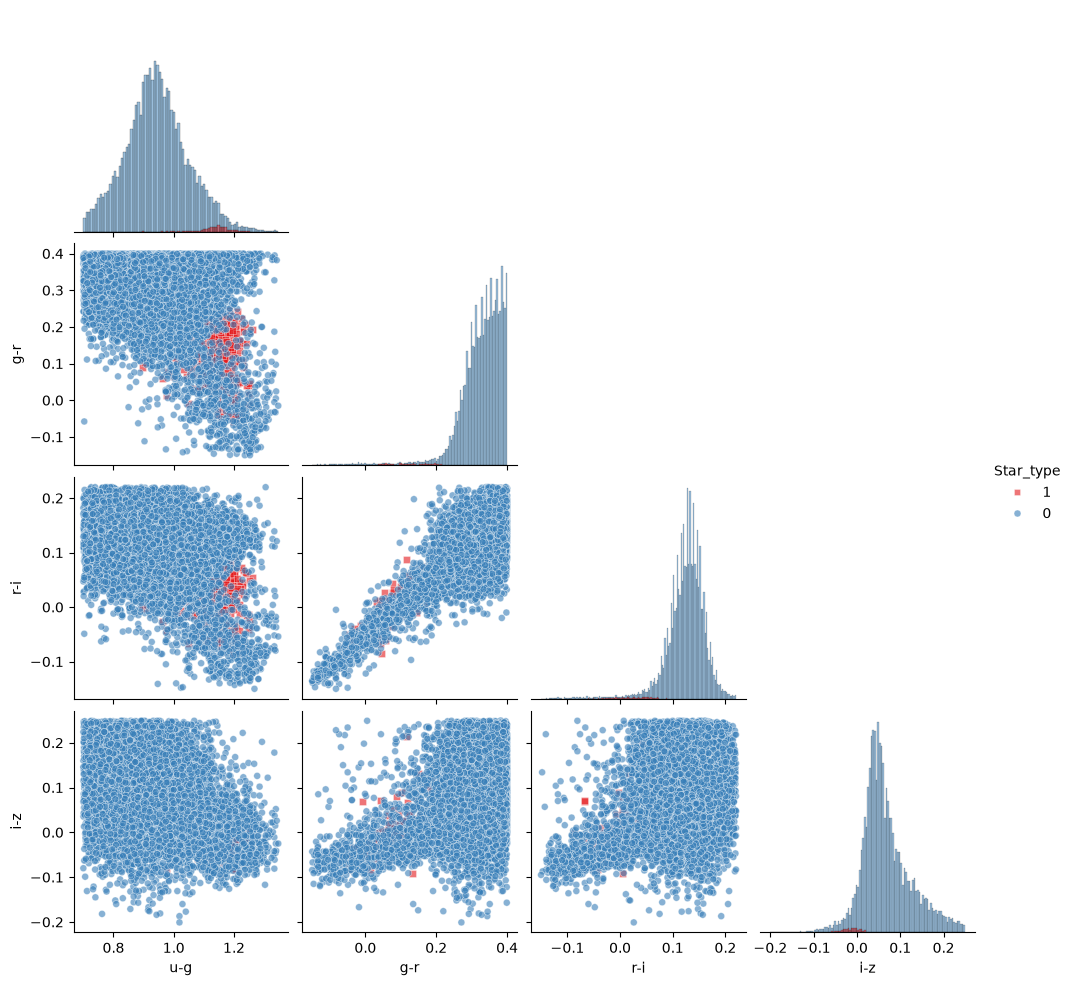

In [11]:
# Create a corner plot with scatter plots colored by star type
g = sns.pairplot(
    df,
    hue="Star_type",
    hue_order = [1,0],
    corner=True,  # Keeps only the lower triangle (corner plot format)
    palette="Set1",  # Color palette for star types
    markers=["o", "s"],  # Different markers for each star type
    plot_kws={"alpha": 0.6, "s": 25},  # Adjust marker transparency and size
    diag_kind="hist",  # Diagonal shows Kernel Density Estimate distributions
)

# Optional: Adjust title and layout
#g.suptitle("Corner Plot of Stellar Colors by Star Type", y=1.02)
plt.show()

----

# kNN

## Introduction to k-Nearest Neighbors (kNN)

The **k-Nearest Neighbors** algorithm is one of the simplest yet powerful classification algorithms in machine learning. Here's how it works:

1. **Core Idea**: To classify a new data point, kNN finds the k closest training examples and assigns the label that appears most frequently among those neighbors.

2. **Distance Metric**: By default, it uses Euclidean distance, which measures the straight-line distance between points in feature space.

3. **Why Test Different k Values?**
   - **Small k (e.g., k=1)**: The model is very flexible and sensitive to individual data points. It may overfit the training data.
   - **Large k (e.g., k=30)**: The model becomes more rigid and may underfit, missing important patterns.
   - **Optimal k**: Balances between fitting the training data well and generalizing to new unseen data.

In this tutorial, we'll explore how different k values affect the classification of stars:
- **Class 0**: Normal stars
- **Class 1**: RR Lyrae variable stars (which have distinctive brightness variations)

These star types have different color patterns in the four photometric bands (u, g, r, i, z), which we'll use as features.

### Step 1: Prepare the Data

We split our dataset into two parts:
- **Training Set (80%)**: Used to train the kNN model by building the index of training samples
- **Testing Set (20%)**: Used to evaluate how well the model generalizes to unseen data

The class distribution tells us if the dataset is balanced or if one class dominates.

In [12]:
# Split the data into training and testing sets
# IMPORTANT: Use stratified split to maintain class distribution
X = df[['u-g', 'g-r', 'r-i', 'i-z']]
y = df['Star_type']

### Step 2: Hyperparameter Tuning - Testing Different k Values

Here we systematically test k values from 1 to 40 and measure the accuracy on both training and testing sets.

- **Training Accuracy**: How well the model fits the training data
- **Testing Accuracy**: How well the model generalizes to new, unseen data (more important!)

A large gap between training and testing accuracy indicates **overfitting** - the model memorized the training data but doesn't generalize well.

In [27]:
# Test different values of k
k_values = range(1, 41)
train_accuracies = []
test_accuracies = []

In [28]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


# Loop over each k value
for k in k_values:
    # Initialize and train the kNN classifier
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    # Predict on training and testing sets
    y_train_pred = knn.predict(X_train)
    y_test_pred = knn.predict(X_test)

    # Calculate and append accuracy scores
    train_accuracies.append(balanced_accuracy_score(y_train, y_train_pred))
    test_accuracies.append(balanced_accuracy_score(y_test, y_test_pred))

    # balanced_accuracy_score is used to account for class imbalance in the dataset

(30036, 4) (7510, 4) (30036,) (7510,)


### Step 3: Visualize the Effect of k on Model Performance

This plot shows:
- **Blue line with circles**: Training accuracy across different k values (usually decreases as k increases)
- **Orange line with squares**: Testing accuracy (what we care about most)

Look for:
- The k value where testing accuracy is highest (the "elbow" or peak)
- The gap between training and testing accuracy (smaller gap = better generalization)
- The point where testing accuracy stabilizes or starts to decrease

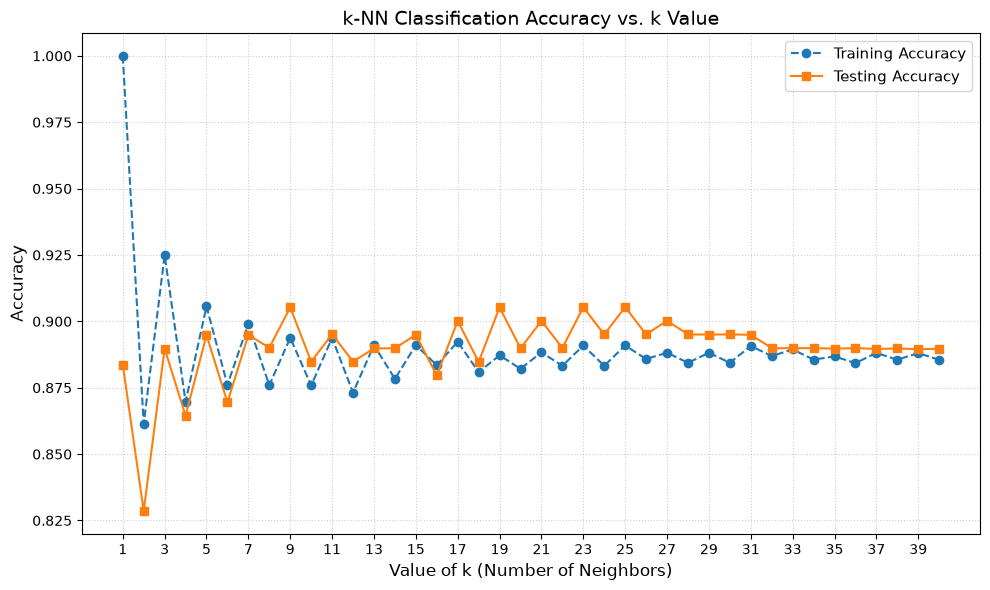

In [29]:
# Visualize how k affects classification accuracy
plt.figure(figsize=(10, 6))

# Plot training and testing accuracies
plt.plot(
    k_values,
    train_accuracies,
    label="Training Accuracy",
    marker="o",
    linestyle="--",
    color="tab:blue",
)

plt.plot(
    k_values,
    test_accuracies,
    label="Testing Accuracy",
    marker="s",
    linestyle="-",
    color="tab:orange",
)

# Formatting
plt.xlabel("Value of k (Number of Neighbors)", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.title("k-NN Classification Accuracy vs. k Value", fontsize=14)
plt.xticks(range(1, 41, 2))  # Display every 2nd k value on x-axis
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

### Step 4: Detailed Evaluation of the Best Model

Now we evaluate the optimal kNN model using multiple metrics:

**Confusion Matrix** shows:
- **True Positives (TP)**: Correctly identified as RR Lyrae
- **True Negatives (TN)**: Correctly identified as Normal Star  
- **False Positives (FP)**: Incorrectly classified as RR Lyrae (Type I error)
- **False Negatives (FN)**: Incorrectly classified as Normal Star (Type II error)

**Key Metrics**:
- **Precision**: Of all predicted RR Lyrae stars, how many were actually RR Lyrae? (TP / (TP + FP))
- **Recall (Sensitivity)**: Of all actual RR Lyrae stars, how many did we correctly identify? (TP / (TP + FN))
- **F1-Score**: Harmonic mean of precision and recall - a balanced metric
- **Support**: Number of samples in each class

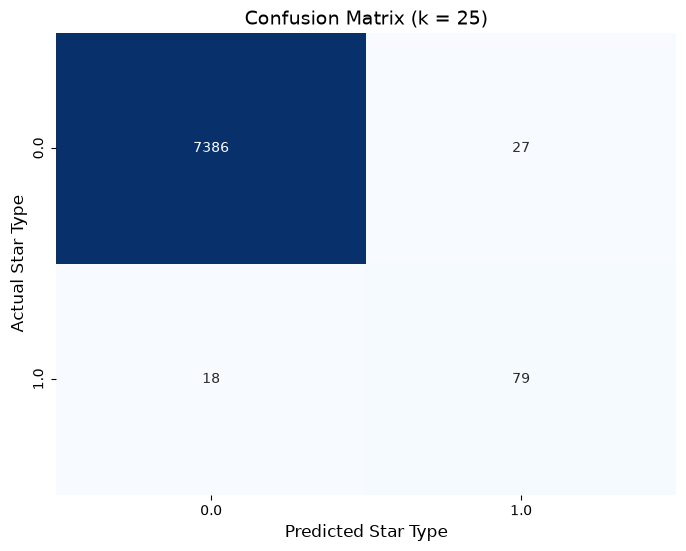

--- Classification Report ---
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      7413
         1.0       0.75      0.81      0.78        97

    accuracy                           0.99      7510
   macro avg       0.87      0.91      0.89      7510
weighted avg       0.99      0.99      0.99      7510



In [16]:
# Train the best kNN model and evaluate in detail
# 1. Train the best kNN model with k = 25
best_k = 25
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train, y_train)

# 2. Make predictions on the testing set
y_pred = best_knn.predict(X_test)

# 3. Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 4. Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=sorted(y.unique()),
    yticklabels=sorted(y.unique()),
)
plt.title(f"Confusion Matrix (k = {best_k})", fontsize=14)
plt.xlabel("Predicted Star Type", fontsize=12)
plt.ylabel("Actual Star Type", fontsize=12)
plt.show()

# 5. Classification Report
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

-----

# Decision Trees Classification

## Introduction to Decision Trees

A **Decision Tree** is a tree-like model that makes predictions by recursively splitting the feature space based on feature values.

**How it works**:
1. The algorithm starts with all data at the root node
2. It selects the feature and threshold that best separates the classes (usually based on Gini impurity or information gain)
3. It recursively splits each node until reaching a stopping criterion
4. Leaf nodes represent class predictions

**Key Concept - Tree Depth**:
- **Shallow trees (small max_depth)**: Simple rules, fast training, may underfit
- **Deep trees (large max_depth)**: Complex rules, can capture intricate patterns, may overfit
- **Optimal depth**: Balances between bias and variance, generalizes well to new data

**Advantages over kNN**:
- Provides **interpretable rules** (you can see exactly how decisions are made)
- Works with both numerical and categorical features
- Doesn't require scaling of features
- Much faster predictions for large datasets

We'll use the same stellar dataset to classify stars as Normal or RR Lyrae using Decision Trees.

### Step 1: Train Decision Trees with Different Depths

We systematically train Decision Trees with maximum depths ranging from 1 to 20. The `max_depth` parameter controls the complexity:
- **max_depth=1**: A single split (stumpy tree, very simple)
- **max_depth=10-15**: Usually where optimal models live
- **max_depth=20+**: Very deep trees that may memorize training data

Like with kNN, we track both training and testing accuracy to detect overfitting.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

# Test different tree depths
depth_values = range(1, 21)
dt_train_accuracies = []
dt_test_accuracies = []

# Loop over each depth value
for depth in depth_values:
    # Initialize and train the Decision Tree classifier
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)

    # Predict on training and testing sets
    y_train_pred = dt.predict(X_train)
    y_test_pred = dt.predict(X_test)

    # Calculate and append balanced accuracy scores
    dt_train_accuracies.append(balanced_accuracy_score(y_train, y_train_pred))
    dt_test_accuracies.append(balanced_accuracy_score(y_test, y_test_pred))

print    

In [41]:
# Create DataFrame
dt_df = pd.DataFrame(
    {"Max Depth": depth_values, "Test Accuracy": dt_test_accuracies}
)

# Format accuracy column as percentage with 2 decimal places
dt_df["Test Accuracy"] = dt_df["Test Accuracy"].apply(
    lambda x: f"{x:.2%}"
)

# Display table
print(dt_df.head(15).to_string(index=False))

 Max Depth Test Accuracy
         1        50.00%
         2        50.00%
         3        88.92%
         4        87.92%
         5        87.43%
         6        87.46%
         7        90.38%
         8        90.42%
         9        89.41%
        10        87.90%
        11        87.38%
        12        87.35%
        13        86.28%
        14        87.37%
        15        86.33%


### Step 2: Visualize the Effect of Tree Depth on Model Performance

This plot compares Decision Tree performance across different depths:
- **Blue line with circles**: Training accuracy (usually stays high or reaches 100% with deep trees)
- **Orange line with squares**: Testing accuracy (the metric we care about most)
- **Red dashed line**: Marks the optimal tree depth

Notice the classic overfitting pattern:
- Training accuracy often reaches 100% for deep trees
- Testing accuracy peaks at an optimal depth, then may decline as the tree becomes too complex
- The gap between training and testing accuracy indicates overfitting severity

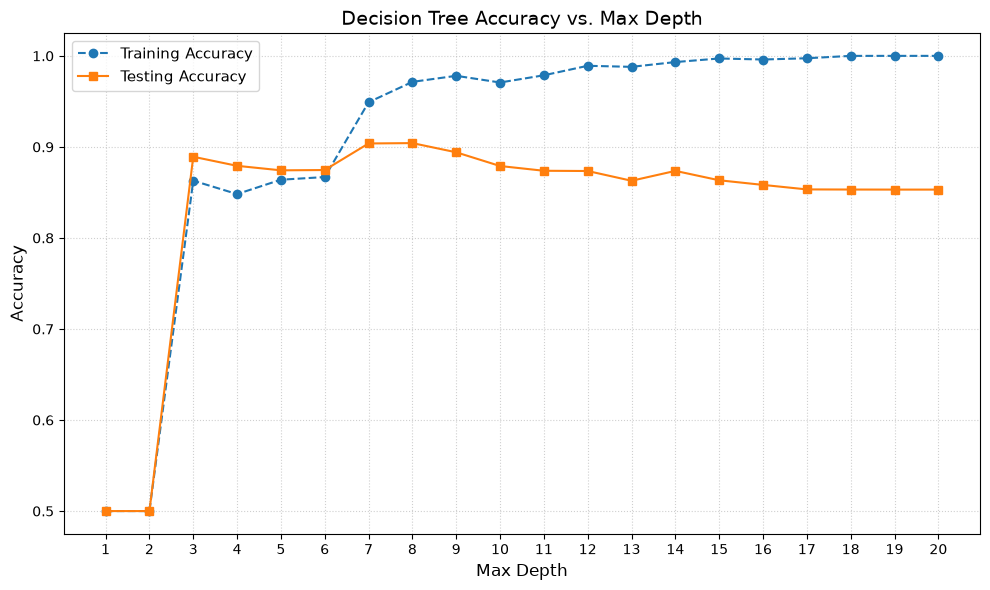

In [45]:
# Visualize how max_depth affects classification accuracy

plt.figure(figsize=(10, 6))
plt.plot(
    depth_values,
    dt_train_accuracies,
    label="Training Accuracy",
    marker="o",
    linestyle="--",
    color="tab:blue",
)
plt.plot(
    depth_values,
    dt_test_accuracies,
    label="Testing Accuracy",
    marker="s",
    linestyle="-",
    color="tab:orange",
)

plt.xlabel("Max Depth", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.title("Decision Tree Accuracy vs. Max Depth", fontsize=14)
plt.xticks(depth_values)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

### Step 3: Detailed Evaluation of the Best Decision Tree Model

The same evaluation metrics as the kNN model apply here:

**Confusion Matrix** shows the classification outcomes:
- **True Positives (TP)**: Correctly identified as RR Lyrae
- **True Negatives (TN)**: Correctly identified as Normal Star  
- **False Positives (FP)**: Incorrectly classified as RR Lyrae
- **False Negatives (FN)**: Incorrectly classified as Normal Star

**Key Metrics**:
- **Precision**: Of all predicted RR Lyrae, how many were actually correct?
- **Recall**: Of all actual RR Lyrae stars, how many did we catch?
- **F1-Score**: Balanced average of precision and recall
- **Support**: Number of samples in each class in the test set

Best max_depth value: 8 with Testing Accuracy: 0.9042


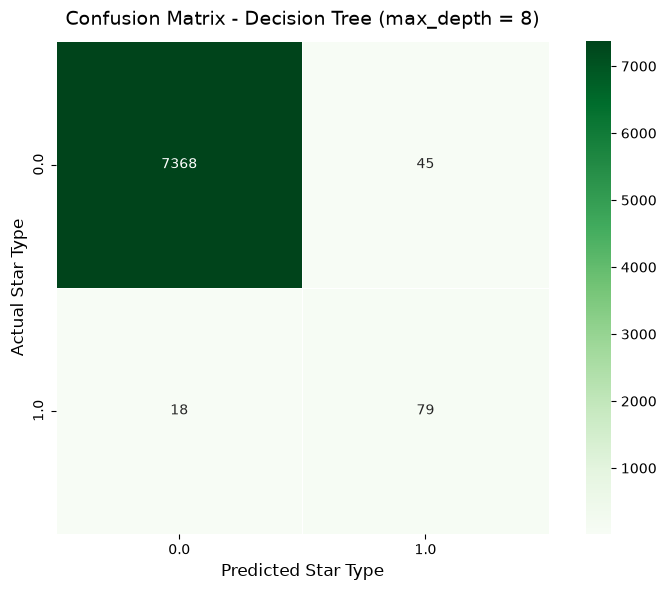

--- Decision Tree Classification Report ---
              precision    recall  f1-score   support

         0.0       1.00      0.99      1.00      7413
         1.0       0.64      0.81      0.71        97

    accuracy                           0.99      7510
   macro avg       0.82      0.90      0.86      7510
weighted avg       0.99      0.99      0.99      7510



In [46]:
# Find the best max_depth value
best_depth = depth_values[np.argmax(dt_test_accuracies)]
print(f"Best max_depth value: {best_depth} with Testing Accuracy: {max(dt_test_accuracies):.4f}")

# Train the best Decision Tree model and evaluate in detail
best_dt = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
best_dt.fit(X_train, y_train)

# Make predictions
y_pred_dt = best_dt.predict(X_test)

# Calculate confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Greens",  # Zmiana koloru dla odróżnienia od kNN
    linewidths=0.5,
    square=True,
    cbar=True,
    xticklabels=sorted(y.unique()),
    yticklabels=sorted(y.unique()),
)

plt.title(
    f"Confusion Matrix - Decision Tree (max_depth = {best_depth})",
    fontsize=14,
    pad=12,
)
plt.xlabel("Predicted Star Type", fontsize=12)
plt.ylabel("Actual Star Type", fontsize=12)

plt.tight_layout()
plt.show()

# 5. Print detailed Classification Report
print("--- Decision Tree Classification Report ---")
print(classification_report(y_test, y_pred_dt))

### Step 4: Visualizing Decision Tree Structures

One of the main advantages of Decision Trees is **interpretability** - we can actually see the decision rules!

The following visualization shows the actual tree structure for three different depths:
- **max_depth=3**: A shallow tree with simple rules
- **max_depth=best_depth**: The optimal tree we selected
- **max_depth=10**: A deeper tree with more complex decision rules

Each node shows:
- **The condition** (feature and threshold) used to split the data
- **Gini impurity** (measure of data purity at that node; 0 means pure, 0.5 means mixed)
- **Sample count** and **value** (how many samples of each class)
- **Color intensity** (darker = more samples of one class, lighter = mixed)

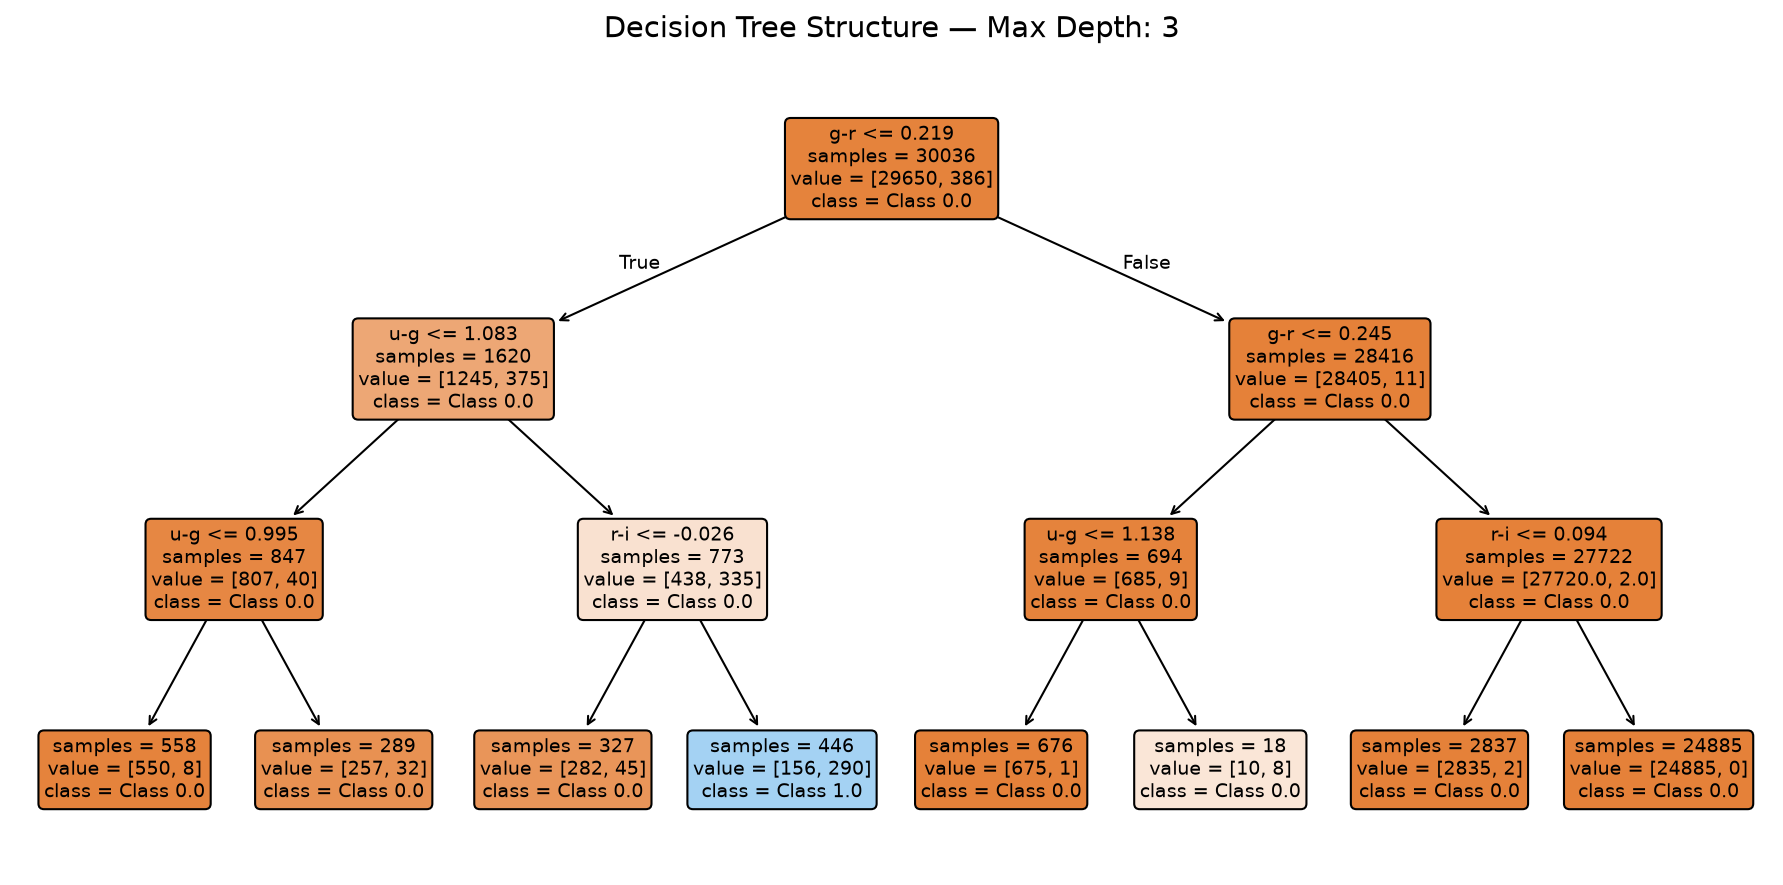

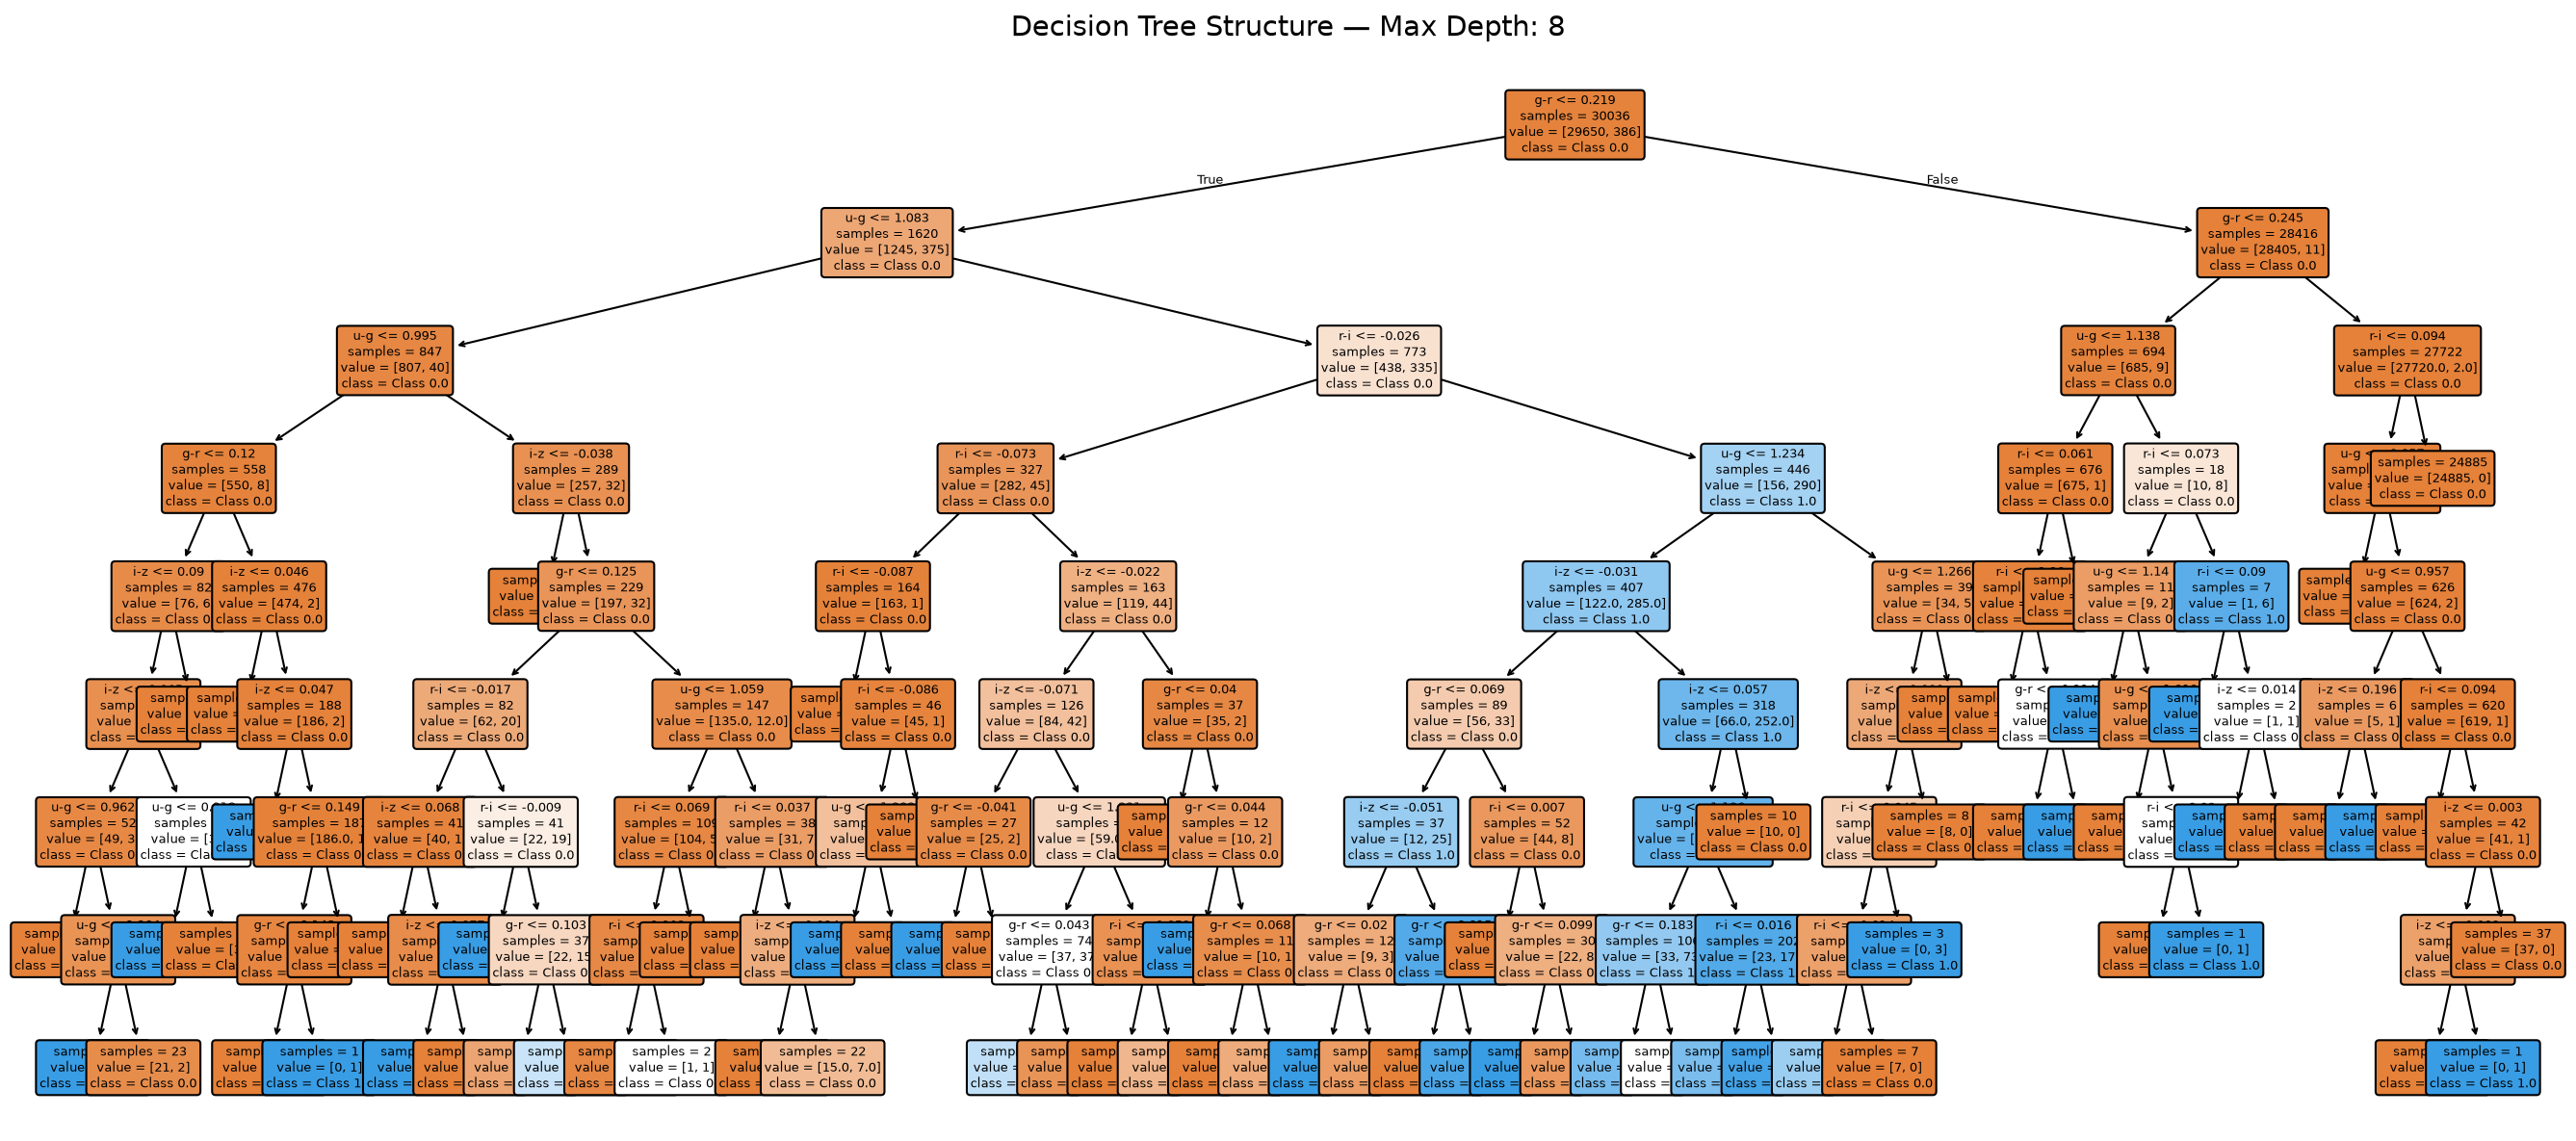

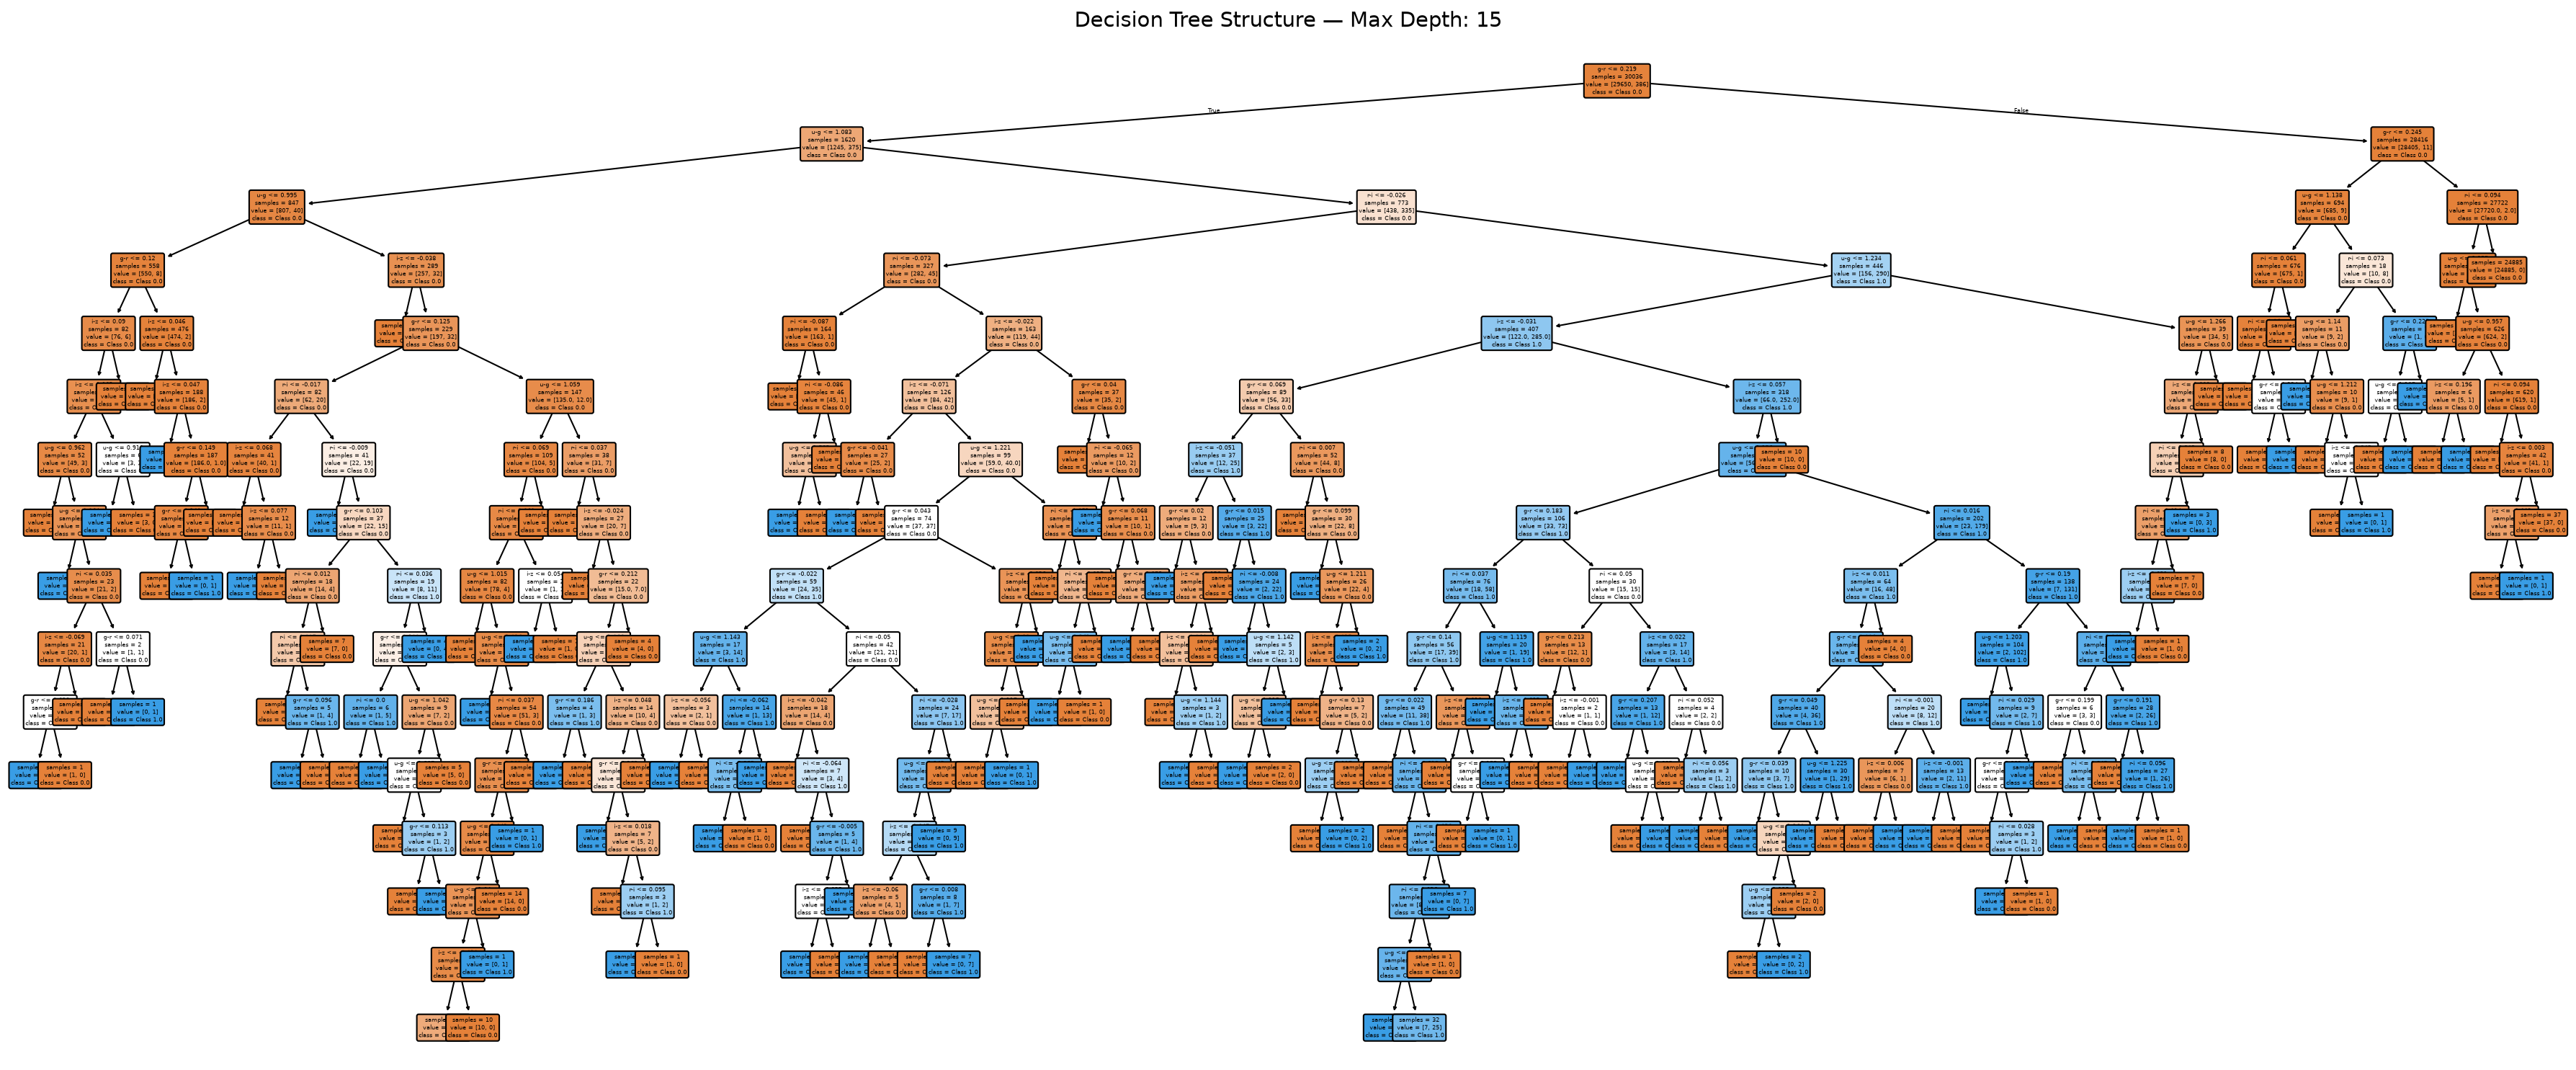

In [55]:
# Define depths to plot individually
depths = [3, 8, 15]

for depth in depths:
    # 1. Train Decision Tree at the current depth
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42, criterion='entropy')  # Using 'entropy' for information gain
    dt.fit(X_train, y_train)

    # 2. Set distinct figure sizes based on depth complexity
    if depth == 3:
        fig_size = (12, 6)
        font_sz = 9
    elif depth == 8:
        fig_size = (18, 8)
        font_sz = 6
    else:  # depth == 15
        fig_size = (24, 10)
        font_sz = 4

    plt.figure(figsize=fig_size, dpi=150)

    # 3. Plot tree with color coding (filled=True colors nodes by target class)
    plot_tree(
        dt,
        feature_names=X.columns,
        class_names=[f"Class {c}" for c in sorted(y.unique())],
        filled=True,  # Color-codes nodes according to target class & purity
        rounded=True,  # Rounded node boxes for cleaner look
        impurity=False,  # Hides Gini value to simplify text inside boxes
        fontsize=font_sz,
    )

    plt.title(
        f"Decision Tree Structure — Max Depth: {depth}", fontsize=14, pad=15
    )
    plt.tight_layout()
    plt.show()

### Step 5: k-Fold Cross Validation for Robust Hyperparameter Selection

In the previous approach, we split the data once into training and testing sets. However, the results can be **sensitive to how the data is split**. A more robust approach is **k-Fold Cross Validation**:

**How k-Fold Cross Validation Works**:
1. Divide the entire dataset into k equal-sized folds (e.g., 5 folds)
2. For each fold:
   - Use that fold as the **test set**
   - Use all other folds as the **training set**
   - Train the model and record the accuracy
3. Calculate the **mean accuracy** and **standard deviation** across all folds
4. The standard deviation tells us how stable the model is across different data splits

**Advantages**:
- **More reliable estimates**: Uses all data for both training and testing
- **Stability assessment**: Standard deviation shows if performance varies across folds
- **Better use of limited data**: No data is wasted (unlike a single train-test split)
- **Reduces variance**: Multiple splits give a more robust estimate of true performance

In [56]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

# Use 5-fold cross validation
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# Test different tree depths using cross validation

# Range of tree depths to evaluate
depths = range(1, 21)

cv_mean_scores = []
cv_std_scores = []

# Evaluate each depth with 5-fold CV
for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)

    # Calculate cross-validation accuracy across folds
    scores = cross_val_score(dt, X_train, y_train, cv=kf, scoring="accuracy")

    cv_mean_scores.append(scores.mean())
    cv_std_scores.append(scores.std())

# Find optimal depth based on highest mean cross-validation accuracy
best_depth_cv = depths[np.argmax(cv_mean_scores)]
best_score = max(cv_mean_scores)

print(
    f"Best Tree Depth (CV): {best_depth_cv} with Mean CV Accuracy: {best_score:.4f}"
)

Best Tree Depth (CV): 5 with Mean CV Accuracy: 0.9924


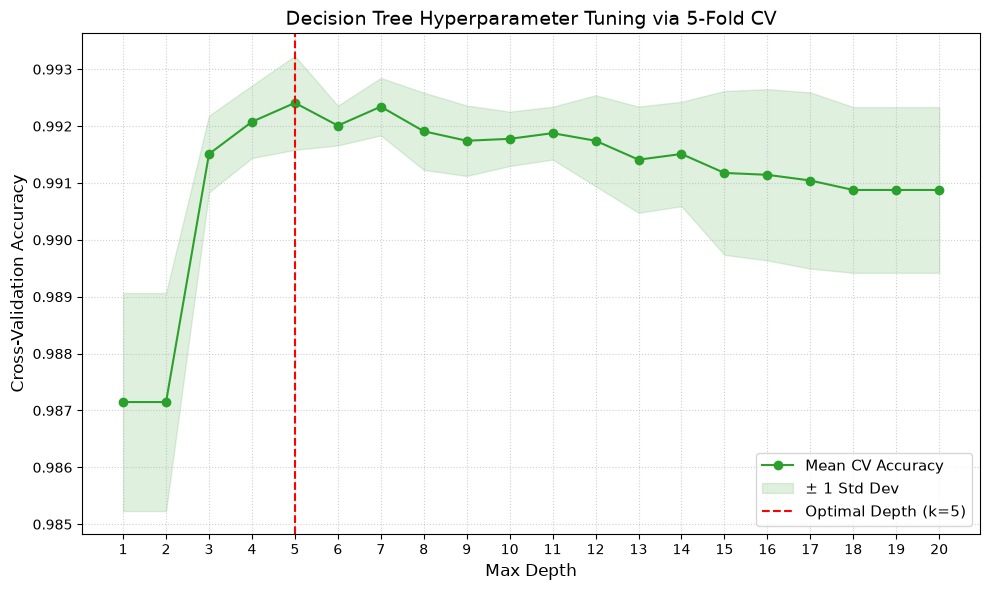


--- Cross-Validation Results Summary ---
 Max Depth Mean CV Accuracy  Std Dev
         1           98.71% 0.001917
         2           98.71% 0.001917
         3           99.15% 0.000674
         4           99.21% 0.000637
         5           99.24% 0.000826
         6           99.20% 0.000349
         7           99.23% 0.000505
         8           99.19% 0.000679
         9           99.17% 0.000620
        10           99.18% 0.000478
        11           99.19% 0.000464
        12           99.17% 0.000799
        13           99.14% 0.000934
        14           99.15% 0.000918
        15           99.12% 0.001440
        16           99.11% 0.001506
        17           99.10% 0.001549
        18           99.09% 0.001457
        19           99.09% 0.001457
        20           99.09% 0.001457


In [57]:
# Plot Mean CV Accuracy vs. Depth
plt.figure(figsize=(10, 6))
plt.plot(
    depths,
    cv_mean_scores,
    marker="o",
    linestyle="-",
    color="tab:green",
    label="Mean CV Accuracy",
)

# Optional: Add shaded error band for standard deviation across folds
plt.fill_between(
    depths,
    np.array(cv_mean_scores) - np.array(cv_std_scores),
    np.array(cv_mean_scores) + np.array(cv_std_scores),
    alpha=0.15,
    color="tab:green",
    label="± 1 Std Dev",
)

plt.axvline(
    x=best_depth_cv,
    color="red",
    linestyle="--",
    label=f"Optimal Depth (k={best_depth_cv})",
)

plt.xlabel("Max Depth", fontsize=12)
plt.ylabel("Cross-Validation Accuracy", fontsize=12)
plt.title("Decision Tree Hyperparameter Tuning via 5-Fold CV", fontsize=14)
plt.xticks(depths)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

# Display summary results in a DataFrame
results_cv = pd.DataFrame(
    {
        "Max Depth": depths,
        "Mean CV Accuracy": cv_mean_scores,
        "Std Dev": cv_std_scores,
    }
)

results_cv["Mean CV Accuracy"] = results_cv["Mean CV Accuracy"].apply(
    lambda x: f"{x:.2%}"
)
print("\n--- Cross-Validation Results Summary ---")
print(results_cv.to_string(index=False))

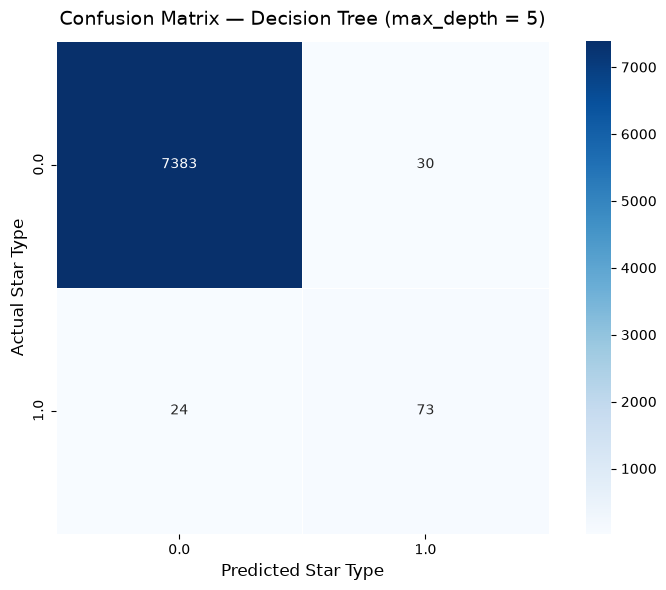

--- Decision Tree Classification Report ---
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      7413
         1.0       0.71      0.75      0.73        97

    accuracy                           0.99      7510
   macro avg       0.85      0.87      0.86      7510
weighted avg       0.99      0.99      0.99      7510



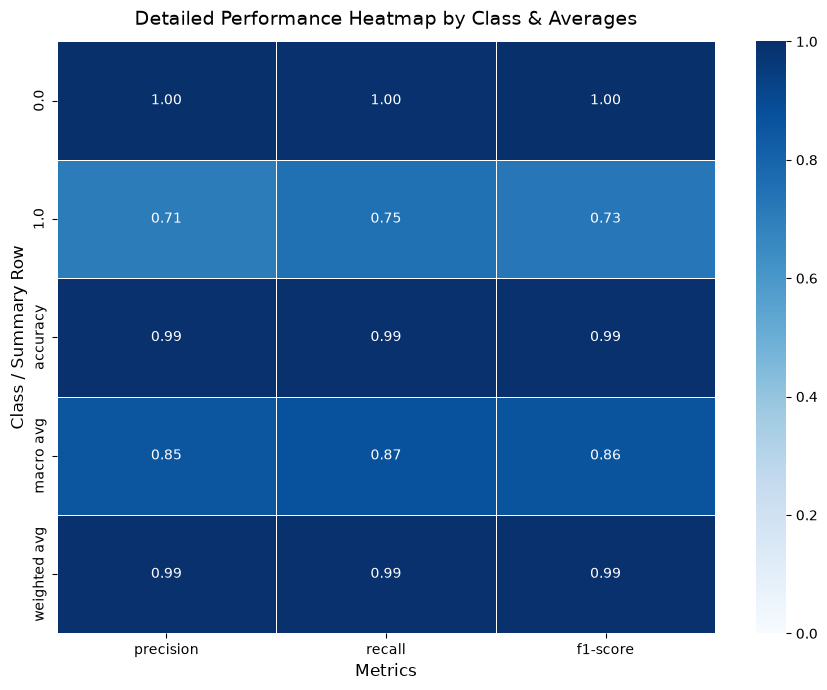

In [60]:
# Train the best Decision Tree model and evaluate in detail

best_dt = DecisionTreeClassifier(max_depth=best_depth_cv, random_state=42)
best_dt.fit(X_train, y_train)

# 2. Make predictions on the test dataset
y_pred_dt = best_dt.predict(X_test)

# 3. Calculate the confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

# 4. Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    square=True,
    cbar=True,
    xticklabels=sorted(y.unique()),
    yticklabels=sorted(y.unique()),
)

plt.title(
    f"Confusion Matrix — Decision Tree (max_depth = {best_depth_cv})",
    fontsize=14,
    pad=12,
)
plt.xlabel("Predicted Star Type", fontsize=12)
plt.ylabel("Actual Star Type", fontsize=12)

plt.tight_layout()
plt.show()

# 5. Print the detailed Classification Report
print("--- Decision Tree Classification Report ---")
print(classification_report(y_test, y_pred_dt))

# Generate classification report as a dictionary
report_dict = classification_report(
    y_test, y_pred_dt, output_dict=True
)

# Convert report to DataFrame and select precision, recall, f1-score for individual classes
report_df = pd.DataFrame(report_dict).T
class_metrics = report_df.drop(
    index=["accuracy", "macro avg", "weighted avg"]
)[["precision", "recall", "f1-score"]]

# Rename index for clearer display
class_metrics.index = [f"Class {idx}" for idx in class_metrics.index]

# Format summary report DataFrame
full_report_df = pd.DataFrame(report_dict).T[["precision", "recall", "f1-score"]]

plt.figure(figsize=(9, 7))
sns.heatmap(
    full_report_df,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=0,
    vmax=1,
    linewidths=0.5,
)

plt.title("Detailed Performance Heatmap by Class & Averages", fontsize=14, pad=12)
plt.xlabel("Metrics", fontsize=12)
plt.ylabel("Class / Summary Row", fontsize=12)

plt.tight_layout()
plt.show()

------

# Random Forest Classification

## Introduction to Random Forests

A **Random Forest** is an ensemble learning method that combines multiple decision trees to create a more powerful and robust classifier.

**How it works**:
1. Creates multiple decision trees, each trained on a random subset of the data (with replacement - "bootstrap samples")
2. Each tree also uses a random subset of features at each split
3. For predictions, each tree "votes" and the majority class wins
4. This ensemble approach reduces overfitting compared to a single tree

**Key Advantages**:
- **Reduces overfitting**: Averaging predictions from multiple trees is more robust than a single tree
- **Handles high-dimensional data**: Random feature selection at each split
- **Provides feature importance**: Shows which features are most important for classification
- **Parallelizable**: Trees can be built independently in parallel
- **Out-of-bag (OOB) error**: Can estimate performance without a separate test set

**Key Hyperparameters**:
- **n_estimators**: Number of trees in the forest (more trees = better, but slower)
- **max_depth**: Maximum depth of each tree (controls complexity of individual trees)
- **min_samples_split**: Minimum samples required to split a node (controls tree growth)

We'll use the same stellar dataset to classify stars as Normal or RR Lyrae using Random Forests.

### Step 1: Train Random Forests with Different Numbers of Trees

We'll test Random Forests with different numbers of trees (n_estimators) ranging from 1 to 200.

**Why n_estimators matters**:
- **n_estimators=1**: Just a single random tree, similar to a decision tree
- **n_estimators=10-50**: Good balance between performance and computational cost
- **n_estimators=100+**: More robust predictions, but diminishing returns
- **Very large n_estimators**: More stable predictions but slower training and prediction

In [61]:
from sklearn.ensemble import RandomForestClassifier

# Test different numbers of trees
n_estimators_range = [10, 25, 50, 100, 150, 200, 300]
rf_train_accuracies = []
rf_test_accuracies = []

# Loop over each n_estimators value
for n_trees in n_estimators_range:
    # Initialize and fit Random Forest classifier
    rf = RandomForestClassifier(
        n_estimators=n_trees, random_state=42, n_jobs=-1
    )
    rf.fit(X_train, y_train)

    # Make predictions
    y_train_pred = rf.predict(X_train)
    y_test_pred = rf.predict(X_test)

    # Record accuracy scores
    rf_train_accuracies.append(accuracy_score(y_train, y_train_pred))
    rf_test_accuracies.append(accuracy_score(y_test, y_test_pred))

print("Training Random Forests with different numbers of trees...\n")

Training Random Forests with different numbers of trees...



### Step 2: Visualize the Effect of Number of Trees on Performance

This plot shows how the number of trees affects model performance:
- **Blue line with circles**: Training accuracy (usually stays high or reaches 100%)
- **Orange line with squares**: Testing accuracy (what we care about most)

Key observations:
- Performance typically improves quickly as we add more trees
- After a certain point, adding more trees shows diminishing returns
- Unlike single decision trees, Random Forests typically don't overfit as much

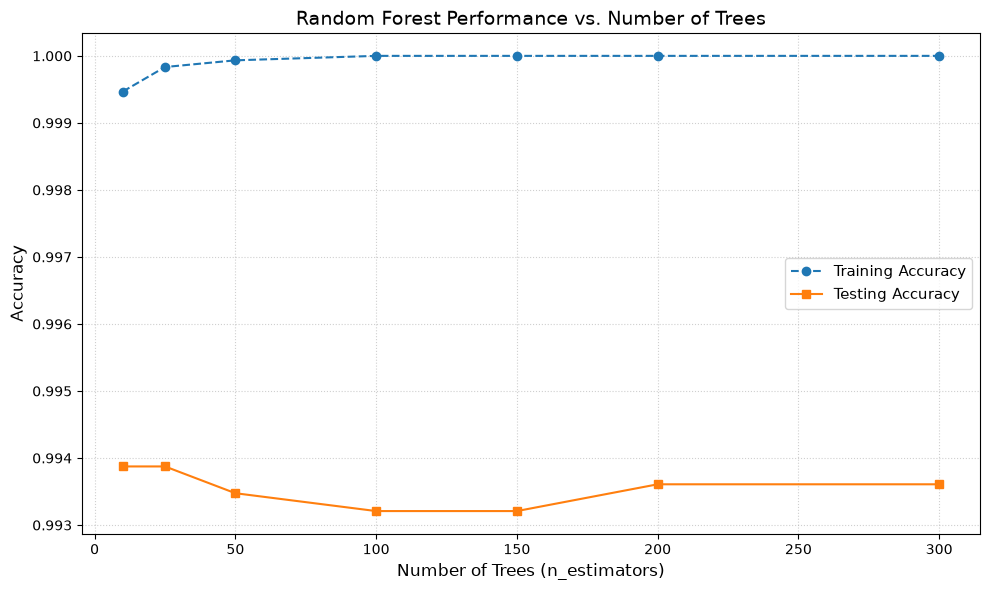

 n_estimators Train Accuracy Test Accuracy
           10         99.95%        99.39%
           25         99.98%        99.39%
           50         99.99%        99.35%
          100        100.00%        99.32%
          150        100.00%        99.32%
          200        100.00%        99.36%
          300        100.00%        99.36%


In [62]:
# Visualize how n_estimators affects Random Forest performance
# Plot performance curve
plt.figure(figsize=(10, 6))
plt.plot(
    n_estimators_range,
    rf_train_accuracies,
    label="Training Accuracy",
    marker="o",
    linestyle="--",
    color="tab:blue",
)
plt.plot(
    n_estimators_range,
    rf_test_accuracies,
    label="Testing Accuracy",
    marker="s",
    linestyle="-",
    color="tab:orange",
)

plt.xlabel("Number of Trees (n_estimators)", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.title("Random Forest Performance vs. Number of Trees", fontsize=14)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

# Display summary table
rf_results = pd.DataFrame(
    {
        "n_estimators": n_estimators_range,
        "Train Accuracy": [f"{acc:.2%}" for acc in rf_train_accuracies],
        "Test Accuracy": [f"{acc:.2%}" for acc in rf_test_accuracies],
    }
)

print(rf_results.to_string(index=False))

### Step 3: Detailed Evaluation of the Best Random Forest Model

The confusion matrix and classification report provide detailed insights into the model's performance.

Optimal n_estimators: 10


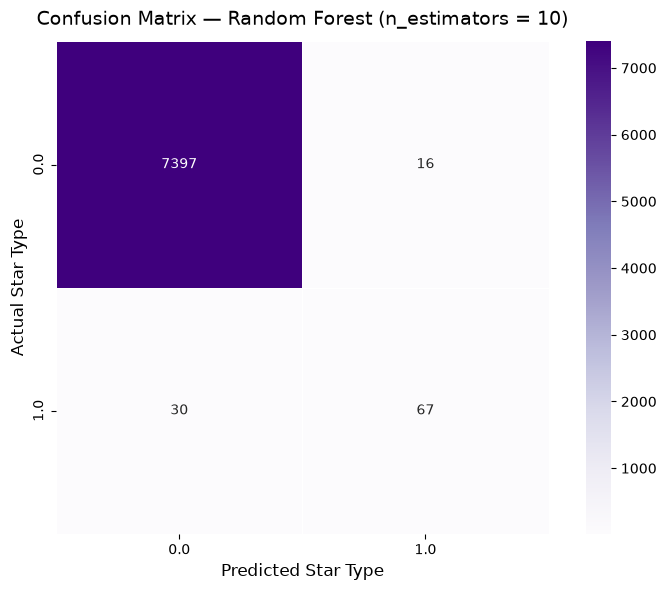

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      7413
         1.0       0.81      0.69      0.74        97

    accuracy                           0.99      7510
   macro avg       0.90      0.84      0.87      7510
weighted avg       0.99      0.99      0.99      7510



In [63]:
best_idx = rf_test_accuracies.index(max(rf_test_accuracies))
best_n_estimators = n_estimators_range[best_idx]

print(f"Optimal n_estimators: {best_n_estimators}")

# 2. Train the best Random Forest model
best_rf = RandomForestClassifier(
    n_estimators=best_n_estimators, random_state=42, n_jobs=-1
)
best_rf.fit(X_train, y_train)

# 3. Make predictions on test set
y_pred_rf = best_rf.predict(X_test)

# 4. Calculate confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

# 5. Plot confusion matrix heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Purples",
    linewidths=0.5,
    square=True,
    cbar=True,
    xticklabels=sorted(y.unique()),
    yticklabels=sorted(y.unique()),
)

plt.title(
    f"Confusion Matrix — Random Forest (n_estimators = {best_n_estimators})",
    fontsize=14,
    pad=12,
)
plt.xlabel("Predicted Star Type", fontsize=12)
plt.ylabel("Actual Star Type", fontsize=12)

plt.tight_layout()
plt.show()

# 6. Print Classification Report
print("--- Random Forest Classification Report ---")
print(classification_report(y_test, y_pred_rf))

### Step 4: Feature Importance Analysis

One of the key advantages of Random Forests is that they provide **feature importance** - a measure of how much each feature contributes to the classification.

The importance is based on how much each feature decreases the impurity (Gini or entropy) across all trees in the forest. Features that are more important for separating the classes will have higher importance scores.

/tmp/ipykernel_23833/1014847380.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="viridis")


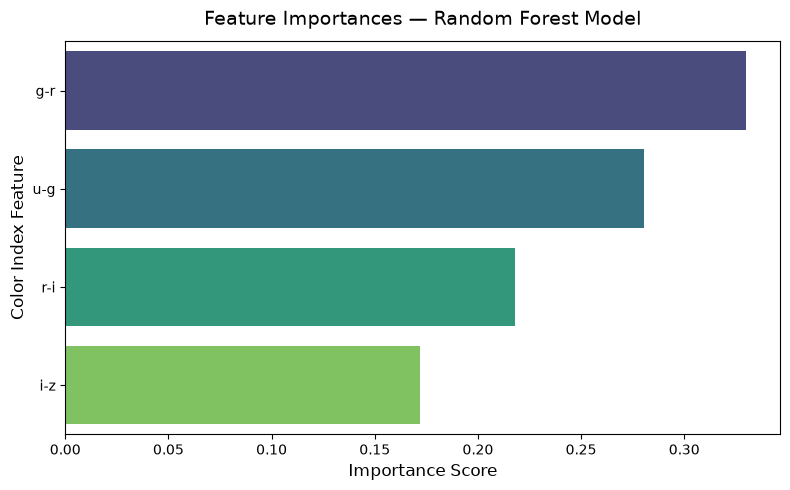

In [64]:
# Extract feature importances
importances = pd.Series(
    best_rf.feature_importances_, index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index, palette="viridis")

plt.title("Feature Importances — Random Forest Model", fontsize=14, pad=12)
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Color Index Feature", fontsize=12)

plt.tight_layout()
plt.show()

### Step 5: Cross Validation Evaluation of Random Forest

Let's use k-fold cross validation to robustly evaluate the Random Forest model with different numbers of trees.

In [66]:
# 1. Set up 5-Fold Cross-Validation
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# Define the candidate range for n_estimators
n_estimators_range = [10, 25, 50, 100, 150, 200, 300]

rf_cv_means = []
rf_cv_stds = []

# 2. Evaluate each n_estimators value across 5 folds
for n_trees in n_estimators_range:
    rf = RandomForestClassifier(
        n_estimators=n_trees, random_state=42, n_jobs=-1
    )

    # Perform 5-fold cross-validation on training data
    scores = cross_val_score(rf, X_train, y_train, cv=kf, scoring="accuracy")

    rf_cv_means.append(scores.mean())
    rf_cv_stds.append(scores.std())

# 3. Identify the best n_estimators
best_rf_idx = np.argmax(rf_cv_means)
best_n_estimators_cv = n_estimators_range[best_rf_idx]
best_cv_score = rf_cv_means[best_rf_idx]

print(
    f"Optimal n_estimators (5-Fold CV): {best_n_estimators_cv} with Mean CV Accuracy: {best_cv_score:.4f}"
)

Optimal n_estimators (5-Fold CV): 200 with Mean CV Accuracy: 0.9939


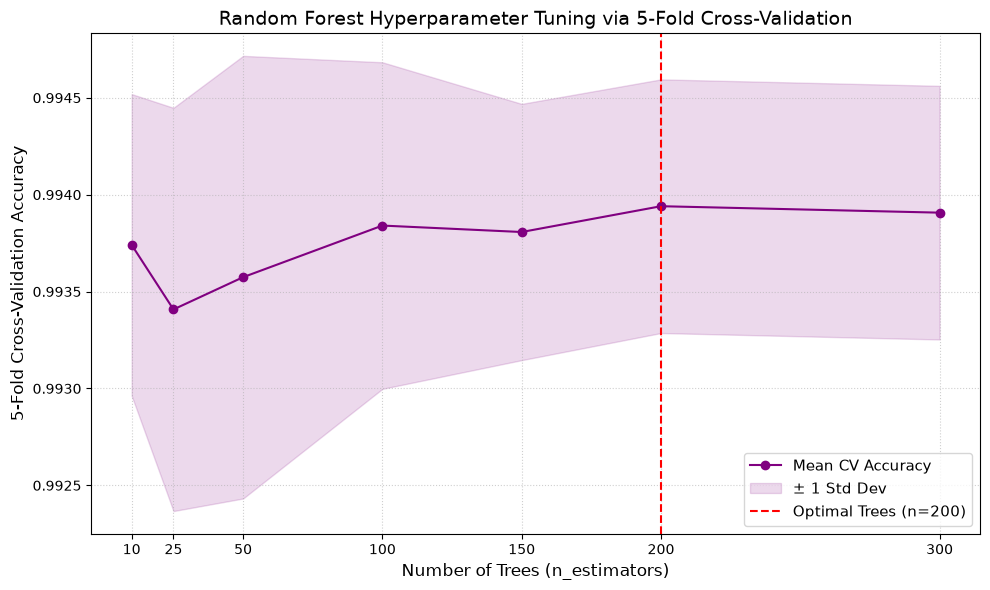


--- Random Forest 5-Fold CV Results ---
 n_estimators Mean CV Accuracy Std Dev
           10           99.37%  0.0008
           25           99.34%  0.0010
           50           99.36%  0.0011
          100           99.38%  0.0008
          150           99.38%  0.0007
          200           99.39%  0.0007
          300           99.39%  0.0007


In [67]:
# Visualize cross validation results
# 4. Plot Mean CV Accuracy vs. n_estimators
plt.figure(figsize=(10, 6))
plt.plot(
    n_estimators_range,
    rf_cv_means,
    marker="o",
    linestyle="-",
    color="purple",
    label="Mean CV Accuracy",
)

# Shaded band for standard deviation across folds
plt.fill_between(
    n_estimators_range,
    np.array(rf_cv_means) - np.array(rf_cv_stds),
    np.array(rf_cv_means) + np.array(rf_cv_stds),
    alpha=0.15,
    color="purple",
    label="± 1 Std Dev",
)

plt.axvline(
    x=best_n_estimators_cv,
    color="red",
    linestyle="--",
    label=f"Optimal Trees (n={best_n_estimators_cv})",
)

plt.xlabel("Number of Trees (n_estimators)", fontsize=12)
plt.ylabel("5-Fold Cross-Validation Accuracy", fontsize=12)
plt.title(
    "Random Forest Hyperparameter Tuning via 5-Fold Cross-Validation",
    fontsize=14,
)
plt.xticks(n_estimators_range)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

# 5. Display summary table
rf_cv_results = pd.DataFrame(
    {
        "n_estimators": n_estimators_range,
        "Mean CV Accuracy": [f"{score:.2%}" for score in rf_cv_means],
        "Std Dev": [f"{std:.4f}" for std in rf_cv_stds],
    }
)

print("\n--- Random Forest 5-Fold CV Results ---")
print(rf_cv_results.to_string(index=False))

## Step 6. Grid Search for Hyperparameter Tuning

### What is Grid Search?

**Grid Search** is a systematic approach to hyperparameter tuning that exhaustively searches through all combinations of specified hyperparameter values. It's called "grid" because you define a grid of values for each parameter, and the search tests all possible combinations.

### How Grid Search Works

1. **Define Parameter Grid**: Specify ranges or lists of values for each hyperparameter
2. **Create All Combinations**: Generate all possible combinations of parameter values
3. **Cross Validation**: For each combination, evaluate the model using k-fold cross validation
4. **Select Best**: Choose the combination with the best cross-validation score
5. **Final Training**: Train a final model using the best parameters on the full training set

### Key Hyperparameters for Random Forest

- **n_estimators**: Number of decision trees in the forest (more ≠ always better)
- **max_depth**: Maximum depth of each tree (controls complexity)
- **min_samples_split**: Minimum samples required to split a node (prevents small splits)
- **min_samples_leaf**: Minimum samples required at a leaf node (controls final predictions)
- **max_features**: Number of features considered at each split ('sqrt' or 'log2' are common)
- **bootstrap**: Whether to use bootstrap samples for training trees

### Trade-offs in Hyperparameter Selection

| Parameter | Increasing Value | Effect |
|-----------|------------------|--------|
| n_estimators | More trees | Better performance but slower |
| max_depth | Deeper trees | More complex model, risk of overfitting |
| min_samples_split | Higher values | Simpler trees, less overfitting |
| min_samples_leaf | Higher values | Simpler leaf nodes, less overfitting |
| max_features | More features | More complex splits, potentially better patterns |
| bootstrap | True | More diversity, less overfitting |

### Why Use Grid Search?

1. **Finds Parameter Interactions**: Some parameters work better together
2. **Systematic Exploration**: Ensures you don't miss good combinations
3. **Robust Evaluation**: Cross validation gives stable performance estimates
4. **Reproducible**: Results can be replicated and documented
5. **Scalable**: Can be parallelized for faster computation

### When to Use Grid Search vs Other Methods

- **Grid Search**: Good for small to medium parameter spaces, when you have computational resources
- **Random Search**: Better for large parameter spaces, samples random combinations
- **Bayesian Optimization**: For complex spaces where past results guide future searches
- **Manual Tuning**: Only when you have strong prior knowledge about good parameters

In [68]:
# Grid Search for Random Forest Hyperparameter Optimization
# This performs an exhaustive search over specified parameter values for a Random Forest classifier

# 1. Define the parameter grid to search over
param_grid = {
    "n_estimators": [100, 250, 500],  # Number of trees
    "max_depth": [3, 5, 10, 15, None],  # Maximum tree depth (None = unlimited)
    "min_samples_split": [5, 10],  # Minimum samples to split a node
    "max_features": [
        "sqrt",
        "log2",
    ],  # Number of features to consider at each split
    "bootstrap": [True],  # Whether to use bootstrap samples
}

# 2. Create the base Random Forest classifier
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# 3. Perform Grid Search with 5-Fold Cross-Validation
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)

# 4. Fit the grid search on training data
print("Running Grid Search across hyperparameter combinations...")
grid_search.fit(X_train, y_train)

# 5. Extract the best model and parameters
best_rf_model = grid_search.best_estimator_
best_params = grid_search.best_params_
best_cv_accuracy = grid_search.best_score_

print("\n=== Grid Search Optimization Complete ===")
print(f"Best Cross-Validation Accuracy: {best_cv_accuracy:.2%}")
print("Optimal Hyperparameters:")
for param, value in best_params.items():
    print(f"  - {param}: {value}")

# 6. Test the best model on the unseen test set
y_test_pred = best_rf_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"\nFinal Test Set Accuracy: {test_accuracy:.2%}")

# Optional: Print detailed evaluation report for the optimized model
print("\n--- Optimized Random Forest Classification Report ---")
print(classification_report(y_test, y_test_pred))

Running Grid Search across hyperparameter combinations...
Fitting 5 folds for each of 60 candidates, totalling 300 fits


/home/dekak/.local/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/dekak/.local/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/dekak/.local/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/dekak/.local/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWa


=== Grid Search Optimization Complete ===
Best Cross-Validation Accuracy: 99.41%
Optimal Hyperparameters:
  - bootstrap: True
  - max_depth: 15
  - max_features: sqrt
  - min_samples_split: 10
  - n_estimators: 250

Final Test Set Accuracy: 99.36%

--- Optimized Random Forest Classification Report ---
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      7413
         1.0       0.78      0.71      0.74        97

    accuracy                           0.99      7510
   macro avg       0.89      0.85      0.87      7510
weighted avg       0.99      0.99      0.99      7510



In [ ]:
# Analyze Grid Search Results
# 1. Convert Grid Search results into a pandas DataFrame
cv_results = pd.DataFrame(grid_search.cv_results_)

# Select key columns for analysis
cols_to_keep = [
    "param_max_depth",
    "param_n_estimators",
    "param_min_samples_split",
    "param_max_features",
    "mean_test_score",
    "std_test_score",
    "rank_test_score",
]

results_summary = (
    cv_results[cols_to_keep]
    .sort_values(by="rank_test_score")
    .reset_index(drop=True)
)

# Rename columns for clarity
results_summary.columns = [
    "Max Depth",
    "n_estimators",
    "Min Samples Split",
    "Max Features",
    "Mean CV Accuracy",
    "Std Dev",
    "Rank",
]

# 2. Display Top 10 Best Hyperparameter Configurations
print("--- Top 10 Hyperparameter Configurations ---")
print(
    results_summary.head(10).to_string(
        index=False, formatters={"Mean CV Accuracy": "{:.2%}".format}
    )
)

# 3. Analyze impact of max_depth vs. n_estimators via Heatmap
pivot_table = cv_results.pivot_table(
    values="mean_test_score",
    index="param_max_depth",
    columns="param_n_estimators",
    aggfunc="mean",
)

# Fill None max_depth label for visualization
pivot_table.index = [
    "None (Unlimited)" if d is None else f"Depth {d}" for d in pivot_table.index
]

plt.figure(figsize=(9, 6))
sns.heatmap(
    pivot_table,
    annot=True,
    fmt=".4f",
    cmap="YlGnBu",
    cbar_kws={"label": "Mean CV Accuracy"},
    linewidths=0.5,
)

plt.title(
    "Mean CV Accuracy Across Tree Depths & Estimators", fontsize=14, pad=12
)
plt.xlabel("Number of Trees (n_estimators)", fontsize=12)
plt.ylabel("Maximum Depth (max_depth)", fontsize=12)

plt.tight_layout()
plt.show()

# 4. Compare feature selection strategies (sqrt vs. log2)
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=cv_results,
    x="param_max_features",
    y="mean_test_score",
    palette="Set2",
)

plt.title(
    "CV Accuracy Distribution by Max Features Strategy", fontsize=14, pad=12
)
plt.xlabel("Max Features Option", fontsize=12)
plt.ylabel("Mean CV Accuracy", fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
# Detailed Evaluation of Best Model from Grid Search
# Create confusion matrix and classification report

In [ ]:
# Comparison: Basic Tuning vs Grid Search
# Compare the model trained with basic n_estimators tuning vs comprehensive grid search

------

# XGBoost Classification

## Introduction to XGBoost (Extreme Gradient Boosting)

**XGBoost** is a highly optimized gradient boosting framework that has become one of the most popular machine learning algorithms for classification and regression tasks.

**How it works**:
1. Builds an ensemble of decision trees sequentially, with each new tree correcting errors made by previous trees
2. Uses gradient descent to minimize a loss function
3. Applies regularization to prevent overfitting (L1 and L2 penalties)
4. Features parallel and distributed computing for speed
5. Uses a technique called "shrinkage" (learning rate) to gradually improve predictions

**Key Advantages**:
- **Superior Performance**: Often achieves state-of-the-art results on classification and regression tasks
- **Handles Imbalanced Data**: Built-in support for `scale_pos_weight` to handle class imbalance
- **Feature Importance**: Provides detailed feature importance rankings
- **Regularization**: L1/L2 regularization reduces overfitting
- **Speed**: Highly optimized and can be parallelized
- **Stability**: More stable predictions than single decision trees

**Key Hyperparameters**:
- **n_estimators**: Number of boosting rounds (trees to build)
- **max_depth**: Maximum depth of each tree (typically 3-10 for XGBoost)
- **learning_rate**: Shrinkage parameter controlling how much each tree contributes (0.01-0.3)
- **min_child_weight**: Minimum sum of weights needed in a child node
- **subsample**: Fraction of samples used for building each tree
- **colsample_bytree**: Fraction of features used for building each tree
- **scale_pos_weight**: Weight for imbalanced classes (important for our RR Lyrae problem!)

We'll optimize these hyperparameters using k-fold cross validation on the stellar classification task.

### Step 1: Hyperparameter Tuning Using k-Fold Cross Validation

XGBoost has many hyperparameters. We'll optimize the most important ones using k-fold cross validation:
- **max_depth**: Controls tree complexity (3-10)
- **learning_rate**: Controls how fast the model learns (0.01-0.3)
- **n_estimators**: Number of boosting rounds (50-500)

We'll test combinations of these and track balanced accuracy to find the best configuration.

In [ ]:
# Import XGBoost
import xgboost as xgb

In [ ]:
# Visualize grid search results

### Step 2: Detailed Evaluation of the Best XGBoost Model

Now we evaluate the optimized XGBoost model on the test set using our comprehensive metrics.

In [ ]:
# Make predictions with the best XGBoost model

# Calculate confusion matrix

# Plot confusion matrix

# Classification Report

# Calculate metrics for comparison

### Step 3: Feature Importance Analysis for XGBoost

XGBoost provides detailed feature importance information showing how many times each feature was used for splitting across all trees.

In [ ]:
# Extract feature importances from XGBoost

# Print feature importances

# Visualize feature importance

-----

# Comprehensive Algorithm Comparison - All Methods

Now let's compare all four classification algorithms: kNN, Decision Tree, Random Forest, and XGBoost.

In [ ]:
# Calculate metrics for all algorithms
# kNN

# Decision Tree

# Random Forest

# Create comprehensive comparison dataframe